# Phân tích và Đánh giá Tập dữ liệu Kiểm thử GPT-5.5 (Hard & Vanilla Testsets)
Notebook này thực hiện phân tích chi tiết, so sánh đối chiếu giữa hai tập dữ liệu kiểm thử được sinh bởi mô hình ngôn ngữ lớn **GPT-5.5** trong dự án **SecurePrep**:
1. **GPT-5.5 Vanilla Testset** (584 tài liệu)
2. **GPT-5.5 Hard Testset** (2.000 tài liệu)

Nội dung phân tích bao gồm:
* Thống kê mô tả về độ dài văn bản (ký tự, số từ).
* Phân tích mật độ gán nhãn thực thể bảo mật (PII & SPI).
* Đánh giá độ đa dạng từ vựng (Moving Average Type-Token Ratio - MATTR) và độ phân tán ngữ nghĩa (Vendi Score).
* Đánh giá chất lượng sinh và tuân thủ định dạng nhãn (`tag_ok`, `missing_coverage`).
* Trực quan hóa dữ liệu và so sánh giữa hai tập dữ liệu kiểm thử.


In [1]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Cấu hình hiển thị biểu đồ
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'  # Tránh lỗi hiển thị tiếng Việt trên biểu đồ


In [2]:
def tokenize(text):
    """Tokenize tiếng Việt đơn giản (tách theo từ/âm tiết)"""
    return re.findall(r'\w+', text.lower(), re.UNICODE)

def calculate_mattr(tokens, window_size=100):
    """Tính Moving Average Type-Token Ratio (MATTR)"""
    n = len(tokens)
    if n == 0:
        return 0.0
    if n < window_size:
        return len(set(tokens)) / n
    
    ttr_sum = 0.0
    num_windows = n - window_size + 1
    for i in range(num_windows):
        window = tokens[i : i + window_size]
        ttr_sum += len(set(window)) / window_size
    return ttr_sum / num_windows

def calculate_vendi_score(texts, sample_size=1000):
    """Tính Vendi Score đo lường độ đa dạng ngữ nghĩa (TF-IDF + Cosine Similarity)"""
    n = len(texts)
    if n == 0:
        return 0.0
    if n == 1:
        return 1.0
    
    if n > sample_size:
        np.random.seed(42)
        indices = np.random.choice(n, sample_size, replace=False)
        texts = [texts[i] for i in indices]
        n = sample_size

    vectorizer = TfidfVectorizer()
    embeddings = vectorizer.fit_transform(texts).toarray()
    K = cosine_similarity(embeddings)
    eigenvalues = np.linalg.eigvalsh(K / n)
    eigenvalues = eigenvalues[eigenvalues > 1e-10]
    entropy = -np.sum(eigenvalues * np.log(eigenvalues))
    vendi_score = np.exp(entropy)
    return float(vendi_score)


In [3]:
# Đường dẫn các tập dữ liệu (nằm cùng thư mục 3-7-2026, notebook ở /code và data ở /output)
# Nên dùng đường dẫn tương đối từ vị trí notebook
data_dir = Path("../output")
vanilla_path = data_dir / "gpt_5.5_testset_vanilla.jsonl"
hard_path = data_dir / "gpt_5.5_testset_hard.jsonl"

def load_dataset(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError:
                    continue
    return records

vanilla_data = load_dataset(vanilla_path)
hard_data = load_dataset(hard_path)

print(f"Đã tải {len(vanilla_data)} tài liệu từ tập Vanilla Testset.")
print(f"Đã tải {len(hard_data)} tài liệu từ tập Hard Testset.")


Đã tải 2000 tài liệu từ tập Vanilla Testset.
Đã tải 2000 tài liệu từ tập Hard Testset.


In [4]:
def process_records(records, dataset_name):
    rows = []
    for idx, r in enumerate(records):
        content = r.get("content", "")
        char_len = len(content)
        tokens = tokenize(content)
        word_len = len(tokens)
        
        spans = r.get("spans", [])
        num_spans = len(spans)
        
        # Đếm số lượng nhãn PII và SPI
        pii_count = sum(1 for s in spans if s.get("label") == "PII")
        spi_count = sum(1 for s in spans if s.get("label") == "SPI")
        
        # Tính tỷ lệ ký tự được gán nhãn
        annotated_chars = 0
        for s in spans:
            annotated_chars += max(0, s.get("end", 0) - s.get("start", 0))
        span_char_density = (annotated_chars / char_len * 100) if char_len > 0 else 0.0
        
        meta = r.get("meta", {})
        tag_ok = meta.get("tag_ok", False)
        missing_fields = meta.get("missing_coverage", [])
        num_missing = len(missing_fields)
        
        # Tính MATTR
        mattr = calculate_mattr(tokens, window_size=100)
        
        rows.append({
            "idx": idx,
            "dataset": dataset_name,
            "char_len": char_len,
            "word_len": word_len,
            "num_spans": num_spans,
            "pii_count": pii_count,
            "spi_count": spi_count,
            "span_char_density": span_char_density,
            "tag_ok": tag_ok,
            "num_missing": num_missing,
            "mattr": mattr
        })
    return pd.DataFrame(rows)

df_vanilla = process_records(vanilla_data, "Vanilla")
df_hard = process_records(hard_data, "Hard")
df_all = pd.concat([df_vanilla, df_hard], ignore_index=True)
print("Dữ liệu tổng hợp:")
df_all.groupby("dataset").size()


Dữ liệu tổng hợp:


dataset
Hard       2000
Vanilla    2000
dtype: int64

## I. Thống Kê Mô Tả Văn Bản (Text Length Analysis)
Dưới đây là bảng thống kê mô tả về độ dài văn bản (theo số ký tự và số từ) và biểu đồ phân phối chi tiết của hai tập dữ liệu kiểm thử.


In [5]:
text_stats = df_all.groupby("dataset")[["char_len", "word_len"]].agg(["mean", "std", "min", "median", "max"])
print("Bảng thống kê mô tả chiều dài tài liệu:")
text_stats.round(2)


Bảng thống kê mô tả chiều dài tài liệu:


char_len                            word_len                          
            mean     std  min  median   max     mean     std  min median   max
dataset                                                                       
Hard     2827.82  962.82  268  2831.5  5325   630.34  214.85   59  630.0  1202
Vanilla  2731.94  935.81  506  2618.5  5889   609.32  208.77  115  587.0  1295

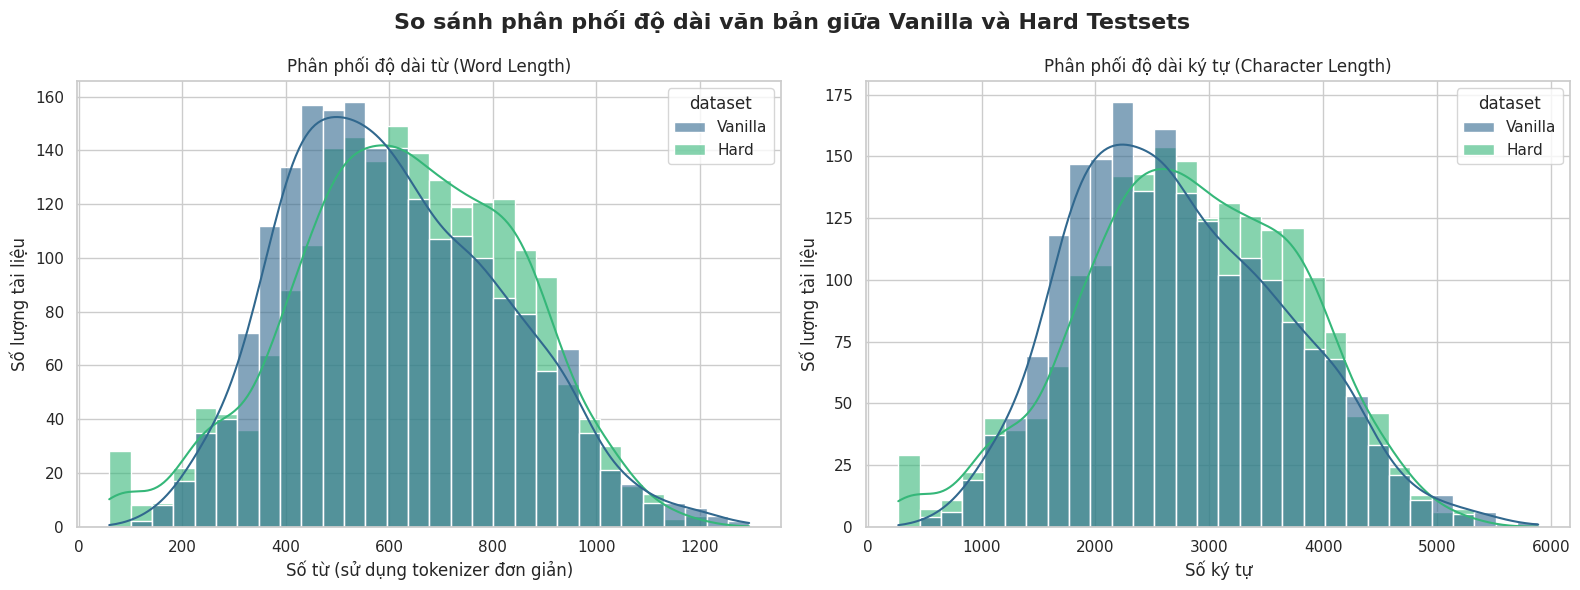

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Phân phối độ dài từ (word length)
sns.histplot(data=df_all, x="word_len", hue="dataset", kde=True, bins=30, ax=axes[0], palette="viridis", alpha=0.6)
axes[0].set_title("Phân phối độ dài từ (Word Length)")
axes[0].set_xlabel("Số từ (sử dụng tokenizer đơn giản)")
axes[0].set_ylabel("Số lượng tài liệu")

# Phân phối độ dài ký tự (character length)
sns.histplot(data=df_all, x="char_len", hue="dataset", kde=True, bins=30, ax=axes[1], palette="viridis", alpha=0.6)
axes[1].set_title("Phân phối độ dài ký tự (Character Length)")
axes[1].set_xlabel("Số ký tự")
axes[1].set_ylabel("Số lượng tài liệu")

plt.suptitle("So sánh phân phối độ dài văn bản giữa Vanilla và Hard Testsets", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## II. Phân Tích Mật Độ Gán Nhãn Thực Thể (Annotation Density Analysis)
Đo lường mức độ phức tạp và mật độ của các nhãn thực thể nhạy cảm (spans) được chèn vào văn bản:
* **Số lượng thực thể gán nhãn trung bình mỗi tài liệu** (Spans per document)
* **Mật độ ký tự được gán nhãn** (Character span density) - Tỷ lệ phần trăm ký tự thực tế thuộc các thực thể nhạy cảm được che giấu trên tổng số ký tự.


In [7]:
density_stats = df_all.groupby("dataset")[["num_spans", "span_char_density"]].agg(["mean", "std", "min", "median", "max"])
print("Bảng thống kê mô tả mật độ gán nhãn:")
density_stats.round(2)


Bảng thống kê mô tả mật độ gán nhãn:


num_spans                      span_char_density                     \
             mean   std min median max              mean   std   min median   
dataset                                                                       
Hard        14.15  4.59   0   14.0  36              7.92  3.64  0.00   7.49   
Vanilla     10.74  3.27   4   10.0  27              6.69  2.88  1.37   6.17   

                
           max  
dataset         
Hard     37.34  
Vanilla  27.73

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21388\3733766488.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x="dataset", y="num_spans", ax=axes[0], palette="Set2", width=0.5)


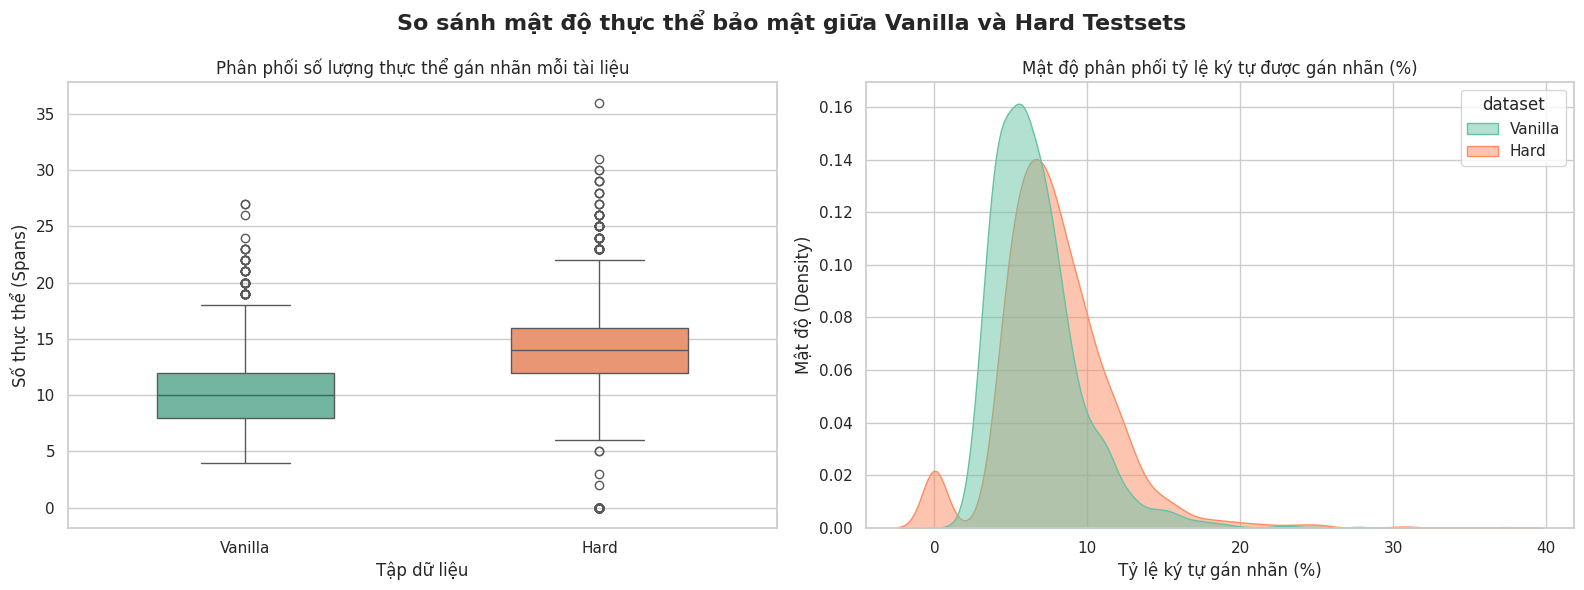

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot số lượng nhãn trên mỗi tài liệu
sns.boxplot(data=df_all, x="dataset", y="num_spans", ax=axes[0], palette="Set2", width=0.5)
axes[0].set_title("Phân phối số lượng thực thể gán nhãn mỗi tài liệu")
axes[0].set_xlabel("Tập dữ liệu")
axes[0].set_ylabel("Số thực thể (Spans)")

# Phân phối mật độ ký tự được gán nhãn (%)
sns.kdeplot(data=df_all, x="span_char_density", hue="dataset", fill=True, common_norm=False, ax=axes[1], palette="Set2", alpha=0.5)
axes[1].set_title("Mật độ phân phối tỷ lệ ký tự được gán nhãn (%)")
axes[1].set_xlabel("Tỷ lệ ký tự gán nhãn (%)")
axes[1].set_ylabel("Mật độ (Density)")

plt.suptitle("So sánh mật độ thực thể bảo mật giữa Vanilla và Hard Testsets", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### Kiểm tra các tài liệu không chứa bất kỳ thực thể gán nhãn nào (Zero-span Documents)
Trong các tác vụ khử định danh hoặc gán nhãn chuỗi bảo mật, điều quan trọng là phải biết liệu có tài liệu nào hoàn toàn trống (không có thực thể nhạy cảm cần che giấu) để đánh giá khả năng dự đoán nhãn âm tính giả (false positive/negative) của mô hình.


In [9]:
# Kiểm tra số lượng tài liệu không có thực thể gán nhãn (num_spans == 0)
no_spans_vanilla = df_vanilla[df_vanilla["num_spans"] == 0]
no_spans_hard = df_hard[df_hard["num_spans"] == 0]

print(f"Tập Vanilla Testset: Có {len(no_spans_vanilla)} tài liệu không chứa thực thể bảo mật nào.")
if len(no_spans_vanilla) > 0:
    print("Mẫu các tài liệu không có thực thể trong tập Vanilla:")
    display(no_spans_vanilla[["idx", "char_len", "word_len", "tag_ok"]])
    
print(f"\nTập Hard Testset: Có {len(no_spans_hard)} tài liệu không chứa thực thể bảo mật nào.")
if len(no_spans_hard) > 0:
    print("Mẫu các tài liệu không có thực thể trong tập Hard:")
    display(no_spans_hard[["idx", "char_len", "word_len", "tag_ok"]])


Tập Vanilla Testset: Có 0 tài liệu không chứa thực thể bảo mật nào.

Tập Hard Testset: Có 85 tài liệu không chứa thực thể bảo mật nào.
Mẫu các tài liệu không có thực thể trong tập Hard:


,idx,char_len,word_len,tag_ok
12,12,1862,413,True
20,20,1568,352,True
25,25,336,73,True
27,27,1678,381,True
30,30,332,74,True
...,...,...,...,...
1952,1952,572,128,True
1953,1953,1207,270,True
1954,1954,1236,275,True
1972,1972,1341,306,True


## III. Phân Phối Dữ Liệu Cá Nhân Cơ Bản (PII) và Nhạy Cảm (SPI)
Theo Nghị định 13/2023/NĐ-CP của Chính phủ về Bảo vệ Dữ liệu Cá nhân (VNDP):
* **Dữ liệu cá nhân cơ bản (PII)**: Họ tên, ngày sinh, giới tính, địa chỉ, số điện thoại, cccd, quốc tịch, v.v.
* **Dữ liệu cá nhân nhạy cảm (SPI)**: Quan điểm chính trị, tôn giáo, tình trạng sức khỏe, đời tư, dữ liệu sinh trắc học, tài khoản ngân hàng, v.v.

Dưới đây là phân tích sự phân bổ giữa hai lớp dữ liệu lớn này.


In [10]:
label_counts = df_all.groupby("dataset")[["pii_count", "spi_count"]].sum()
label_counts["total"] = label_counts["pii_count"] + label_counts["spi_count"]
label_counts["pii_pct"] = (label_counts["pii_count"] / label_counts["total"] * 100).round(2)
label_counts["spi_pct"] = (label_counts["spi_count"] / label_counts["total"] * 100).round(2)
print("Bảng thống kê tỷ lệ phân phối PII vs SPI:")
label_counts


Bảng thống kê tỷ lệ phân phối PII vs SPI:


,pii_count,spi_count,total,pii_pct,spi_pct
dataset,,,,,
Hard,26199,2105,28304,92.56,7.44
Vanilla,19360,2128,21488,90.10,9.90


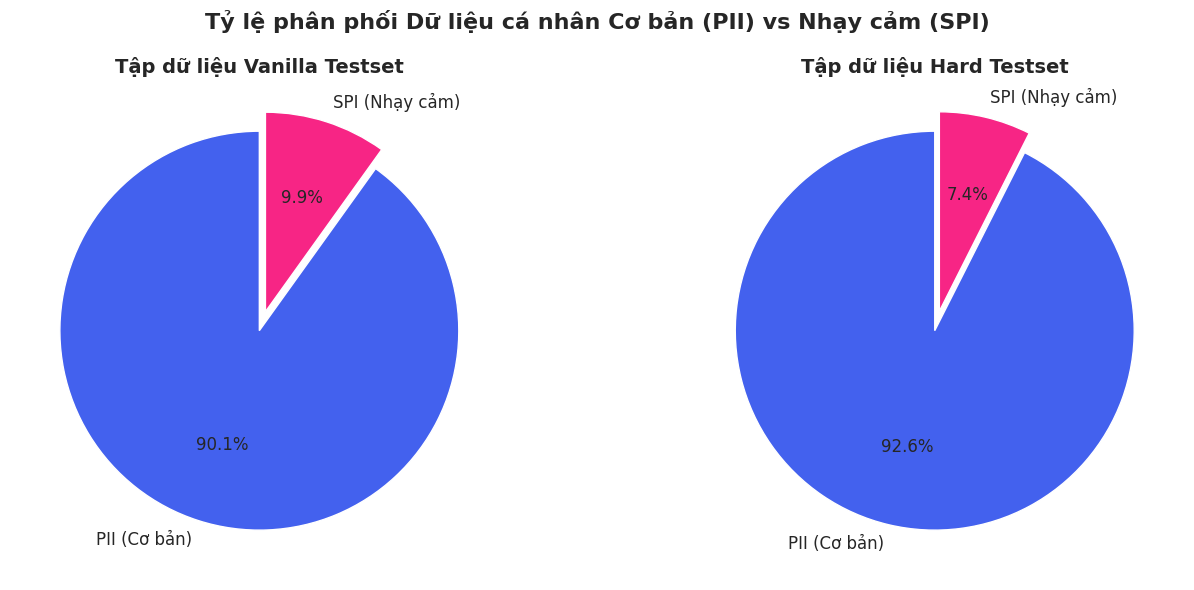

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ["#4361ee", "#f72585"]

# Vanilla Pie Chart
axes[0].pie(
    [label_counts.loc["Vanilla", "pii_count"], label_counts.loc["Vanilla", "spi_count"]],
    labels=["PII (Cơ bản)", "SPI (Nhạy cảm)"],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=(0, 0.1),
    textprops={'fontsize': 12}
)
axes[0].set_title("Tập dữ liệu Vanilla Testset", fontsize=14, fontweight='bold')

# Hard Pie Chart
axes[1].pie(
    [label_counts.loc["Hard", "pii_count"], label_counts.loc["Hard", "spi_count"]],
    labels=["PII (Cơ bản)", "SPI (Nhạy cảm)"],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=(0, 0.1),
    textprops={'fontsize': 12}
)
axes[1].set_title("Tập dữ liệu Hard Testset", fontsize=14, fontweight='bold')

plt.suptitle("Tỷ lệ phân phối Dữ liệu cá nhân Cơ bản (PII) vs Nhạy cảm (SPI)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [12]:
def get_field_distribution(records):
    field_counter = Counter()
    for r in records:
        for s in r.get("spans", []):
            field_counter[s.get("field")] += 1
    return pd.Series(field_counter).sort_values(ascending=False)

vanilla_fields = get_field_distribution(vanilla_data)
hard_fields = get_field_distribution(hard_data)

df_fields = pd.DataFrame({
    "Vanilla": vanilla_fields,
    "Hard": hard_fields
}).fillna(0).astype(int)

df_fields["Vanilla_pct"] = (df_fields["Vanilla"] / df_fields["Vanilla"].sum() * 100).round(2)
df_fields["Hard_pct"] = (df_fields["Hard"] / df_fields["Hard"].sum() * 100).round(2)
print("Thống kê chi tiết 15 trường thực thể xuất hiện nhiều nhất ở tập Hard:")
df_fields.sort_values(by="Hard", ascending=False).head(15)


Thống kê chi tiết 15 trường thực thể xuất hiện nhiều nhất ở tập Hard:


,Vanilla,Hard,Vanilla_pct,Hard_pct
given_name,5257,5744,24.46,20.29
dob,2033,3827,9.46,13.52
phone,2042,3826,9.50,13.52
cccd,2003,3758,9.32,13.28
family_name,3179,2909,14.79,10.28
middle_name,2445,2211,11.38,7.81
address,2030,1910,9.45,6.75
family_relations,59,1701,0.27,6.01
bank_account,515,564,2.40,1.99
location_data,563,521,2.62,1.84


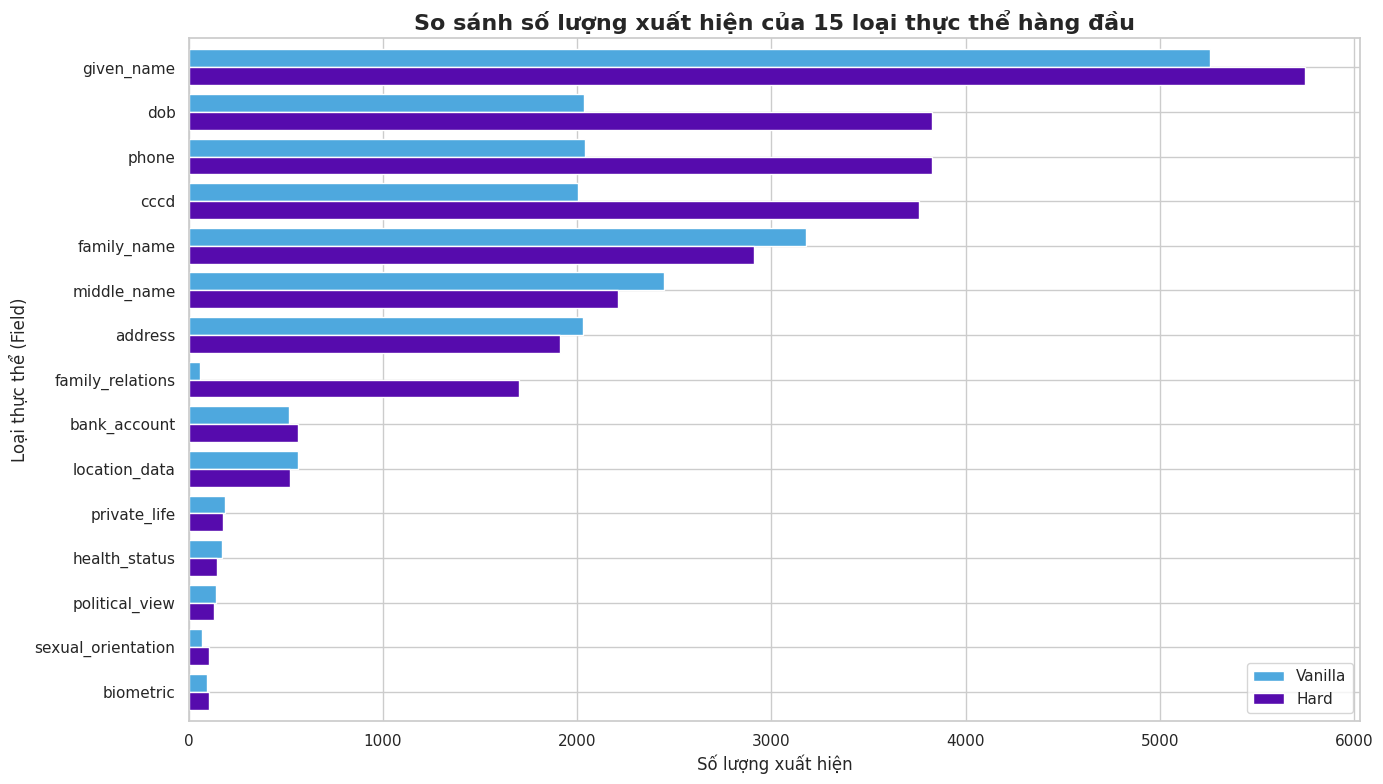

In [13]:
df_fields_top15 = df_fields.sort_values(by="Hard", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 8))
df_fields_top15[["Vanilla", "Hard"]].plot(kind="barh", ax=ax, width=0.8, color=["#4ea8de", "#560bad"])
ax.set_title("So sánh số lượng xuất hiện của 15 loại thực thể hàng đầu", fontsize=16, fontweight='bold')
ax.set_xlabel("Số lượng xuất hiện")
ax.set_ylabel("Loại thực thể (Field)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## IV. Phân Tích Độ Đa Dạng Từ Vựng và Ngữ Nghĩa (Lexical & Semantic Diversity)
Sử dụng các chỉ số:
1. **MATTR (Moving Average Type-Token Ratio, cửa sổ w=100)**: Đo độ đa dạng từ vựng độc lập với chiều dài văn bản. Điểm số càng cao thể hiện khả năng sử dụng từ phong phú, không bị lặp từ.
2. **Vendi Score**: Sử dụng ma trận tương đồng Cosine trên vectơ nhúng TF-IDF của toàn bộ văn bản để đo số lượng tiểu chủ đề độc lập hiệu dụng. Vendi Score cao khẳng định không xảy ra hiện tượng sụp đổ phân phối ngữ nghĩa (mode collapse).


In [14]:
print("Đang tính toán Vendi Score (có thể mất một vài giây do tính toán trị riêng)...")
vendi_vanilla = calculate_vendi_score([r.get("content", "") for r in vanilla_data], sample_size=1000)
vendi_hard = calculate_vendi_score([r.get("content", "") for r in hard_data], sample_size=1000)

diversity_summary = pd.DataFrame({
    "Chỉ số": ["Độ dài từ trung bình", "MATTR (w=100) trung bình", "Vendi Score (s=1000)", "Tỷ lệ phân tán Vendi / Quy mô"],
    "Vanilla Testset": [
        df_vanilla["word_len"].mean(),
        df_vanilla["mattr"].mean(),
        vendi_vanilla,
        vendi_vanilla / len(vanilla_data)
    ],
    "Hard Testset": [
        df_hard["word_len"].mean(),
        df_hard["mattr"].mean(),
        vendi_hard,
        vendi_hard / len(hard_data)
    ]
})
print("Bảng so sánh độ đa dạng ngữ nghĩa và từ vựng:")
diversity_summary.round(4)


Đang tính toán Vendi Score (có thể mất một vài giây do tính toán trị riêng)...


Bảng so sánh độ đa dạng ngữ nghĩa và từ vựng:


,Chỉ số,Vanilla Testset,Hard Testset
0,Độ dài từ trung bình,609.3180,630.3430
1,MATTR (w=100) trung bình,0.7977,0.8229
2,Vendi Score (s=1000),99.3571,94.0347
3,Tỷ lệ phân tán Vendi / Quy mô,0.0497,0.0470


## V. Đánh Giá Sự Tuân Thủ Định Dạng Kỹ Thuật (Compliance & Format Quality)
Đánh giá mức độ hoàn thiện về mặt cú pháp của nhãn sinh ra:
* `tag_ok`: Sự cân bằng và chính xác của cú pháp nhãn HTML/XML được gán nhãn tự động bởi SecurePrep.
* `missing_coverage`: Các trường bị bỏ sót (không được sinh ra mặc dù được quy định trong manifest cấu hình).


In [15]:
compliance_stats = pd.DataFrame({
    "Chỉ số chất lượng": [
        "Tỷ lệ định dạng thẻ hợp lệ (tag_ok %)",
        "Tỷ lệ bao phủ toàn bộ trường bắt buộc (Full Coverage %)",
        "Số lượng tài liệu thiếu trường",
        "Tổng số tài liệu trong tập"
    ],
    "Vanilla Testset": [
        (df_vanilla["tag_ok"].mean() * 100),
        ((df_vanilla["num_missing"] == 0).mean() * 100),
        (df_vanilla["num_missing"] > 0).sum(),
        len(df_vanilla)
    ],
    "Hard Testset": [
        (df_hard["tag_ok"].mean() * 100),
        ((df_hard["num_missing"] == 0).mean() * 100),
        (df_hard["num_missing"] > 0).sum(),
        len(df_hard)
    ]
})
print("Bảng thống kê chất lượng tuân thủ định dạng nhãn:")
compliance_stats.round(2)


Bảng thống kê chất lượng tuân thủ định dạng nhãn:


,Chỉ số chất lượng,Vanilla Testset,Hard Testset
0,Tỷ lệ định dạng thẻ hợp lệ (tag_ok %),100.00,100.0
1,Tỷ lệ bao phủ toàn bộ trường bắt buộc (Full Co...,99.25,95.2
2,Số lượng tài liệu thiếu trường,15.00,96.0
3,Tổng số tài liệu trong tập,2000.00,2000.0


In [16]:
def get_missing_fields_counter(records):
    miss_counter = Counter()
    for r in records:
        miss_fields = r.get("meta", {}).get("missing_coverage", [])
        for f in miss_fields:
            miss_counter[f] += 1
    return pd.Series(miss_counter).sort_values(ascending=False)

vanilla_missed = get_missing_fields_counter(vanilla_data)
hard_missed = get_missing_fields_counter(hard_data)

df_missed = pd.DataFrame({
    "Vanilla": vanilla_missed,
    "Hard": hard_missed
}).fillna(0).astype(int)

print("Các trường thông tin thường bị bỏ sót nhiều nhất (xếp theo tập Hard):")
df_missed.sort_values(by="Hard", ascending=False).head(10)


Các trường thông tin thường bị bỏ sót nhiều nhất (xếp theo tập Hard):


,Vanilla,Hard
marital_status,3,45
dob,0,23
full_name,7,17
gender,5,12
cccd,0,3
phone,0,3
ethnicity,0,2


In [4]:
import json
import re
from pathlib import Path
import pandas as pd

# Đường dẫn tương đối từ thư mục chứa notebook (3-7-2026/code) đến thư mục chứa data (3-7-2026/output)
hard_path = Path("../output/gpt_5.5_testset_hard.jsonl")
vanilla_path = Path("../output/gpt_5.5_testset_vanilla.jsonl")

# Bộ lọc để loại bỏ các địa danh, cơ quan, từ hành chính viết hoa (Tránh nhận diện sai thành tên người)
STOPWORDS_CAP = {
    "Luật", "sư", "Khách", "hàng", "Sở", "UBND", "Ủy", "ban", "nhân", "dân", "Phường", "Quận", "Tỉnh",
    "Căn", "cước", "Công", "dân", "Quyết", "định", "Luật", "Nghị", "định", "Việt", "Nam", "Thành", "phố",
    "Đại", "học", "Trung", "học", "Hồ", "Chí", "Minh", "Hà", "Nội", "Điện", "Biên", "Bắc", "Ninh", "Hải",
    "Phòng", "Đà", "Nẵng", "Cần", "Thơ", "Đồng", "Nai", "Bình", "Dương", "Quảng", "Nam", "Thanh", "Hóa",
    "Nghệ", "An", "Hà", "Tĩnh", "Quảng", "Bình", "Quảng", "Trị", "Thừa", "Thiên", "Huế", "Khánh", "Hòa",
    "Lâm", "Đồng", "Gia", "Lai", "Đắk", "Lắk", "Bình", "Phước", "Tây", "Ninh", "Long", "An", "Tiền", "Giang",
    "Bến", "Tre", "Trà", "Vinh", "Vĩnh", "Long", "Đồng", "Tháp", "An", "Giang", "Kiên", "Giang", "Cà", "Mau",
    "Bạc", "Liêu", "Sóc", "Trăng", "Hậu", "Giang", "Hòa", "Bình", "Sơn", "La", "Lai", "Châu", "Lào", "Cai",
    "Yên", "Bái", "Hà", "Giang", "Tuyên", "Quang", "Cao", "Bằng", "Lạng", "Sơn", "Bắc", "Kạn", "Thái", "Nguyên",
    "Phú", "Thọ", "Vĩnh", "Phúc", "Bắc", "Giang", "Quảng", "Ninh", "Hải", "Dương", "Hưng", "Yên", "Thái", "Bình",
    "Hà", "Nam", "Nam", "Định", "Ninh", "Bình", "Thanh", "Hóa", "Nghệ", "An", "Hà", "Tĩnh", "Quảng", "Bình",
    "Chủ", "tịch", "Giám", "đốc", "Bác", "sĩ", "Bệnh", "viện", "Phòng", "khám", "Cục", "Chi", "cục", "Thuế",
    "Vụ", "Bộ", "Ngân", "hàng", "Công", "ty", "Doanh", "nghiệp", "Hợp", "tác", "xã", "Quy", "định", "Điều",
    "Khoản", "Điểm", "Thông", "tư", "Nghị", "quyết", "Hiến", "pháp", "Bộ", "luật", "Chào", "Vâng", "Cảm", "ơn",
    "Anh", "Chị", "Ông", "Bà", "Cô", "Chú", "Bác", "Dì", "Cậu", "Mẫu", "Đơn", "Tờ", "khai", "Biên", "bản"
}

# Regex tìm tên riêng Việt Nam viết hoa (2-4 từ viết hoa liên tiếp)
NAME_REGEX = re.compile(
    r'\b[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝĐ][a-zà-áâãèéêìíòóôõùúýđ]*(\s+[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝĐ][a-zà-áâãèéêìíòóôõùúýđ]*){1,3}\b'
)

# Regex tìm các cụm từ chỉ mối quan hệ gia đình phổ biến trong văn cảnh sở hữu
FAMILY_MENTION_REGEX = re.compile(
    r'\b(người chồng|chồng tôi|chồng của|người vợ|vợ tôi|vợ của|con ruột|con đẻ|con tôi|con của|con trai|con gái|bố tôi|bố của|bố đẻ|mẹ tôi|mẹ của|mẹ đẻ|cha tôi|cha của|cha đẻ|mẹ ruột|cha ruột|anh ruột|chị ruột|em ruột|anh trai|chị gái|em trai|em gái)\b',
    re.IGNORECASE
)

# Các cụm từ viết liền trước 'bố của' dễ gây nhận diện sai (Ví dụ: "công bố của thủ tục" -> không phải là "bố của")
FALSE_POSITIVE_BEFORE_BO = ["công", "tiến", "tuyên", "phân", "cơ", "sự", "phần", "mật", "bản", "sơ", "bộ"]

def is_valid_name(name_str):
    words = name_str.split()
    if len(words) < 2:
        return False
    # Loại bỏ nếu toàn bộ các từ trong cụm đều thuộc stopwords viết hoa hành chính
    if all(w in STOPWORDS_CAP for w in words):
        return False
    return True

def detect_family_issues(path):
    if not path.exists():
        print(f"Không tìm thấy file tại đường dẫn: {path}")
        return None, None
        
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
                
    issue_1_list = []
    issue_2_list = []
    
    for idx, r in enumerate(records):
        content = r.get("content", "")
        spans = r.get("spans", [])
        profile_id = r.get("profile_id", "N/A")
        
        # --- Phát hiện Lỗi 1: Tên riêng xuất hiện gần nhãn family_relations nhưng không được gán nhãn tên ---
        family_spans = [s for s in spans if s.get("field") == "family_relations"]
        name_span_ranges = []
        for s in spans:
            if s.get("field") in ["family_name", "middle_name", "given_name", "full_name", "name_alias"]:
                name_span_ranges.append((s.get("start", 0), s.get("end", 0)))
                
        for fs in family_spans:
            start, end = fs.get("start", 0), fs.get("end", 0)
            # Quét cửa sổ văn bản 60 ký tự trước và sau nhãn family_relations
            window_start = max(0, start - 60)
            window_end = min(len(content), end + 60)
            window_text = content[window_start:window_end]
            
            for match in NAME_REGEX.finditer(window_text):
                name_str = match.group(0)
                if not is_valid_name(name_str):
                    continue
                
                # Xác định tọa độ tuyệt đối trong văn bản
                name_start_global = window_start + match.start()
                name_end_global = window_start + match.end()
                
                # Kiểm tra xem tọa độ tên này đã có bất kỳ nhãn tên nào bao phủ chưa
                is_tagged = False
                for ns_start, ns_end in name_span_ranges:
                    if not (name_end_global <= ns_start or name_start_global >= ns_end):
                        is_tagged = True
                        break
                        
                if not is_tagged:
                    context = content[max(0, name_start_global - 40): min(len(content), name_end_global + 40)].replace("\n", " ")
                    issue_1_list.append({
                        "idx": idx,
                        "profile_id": profile_id,
                        "family_relation_span": fs.get("text"),
                        "untagged_name": name_str,
                        "context": f"...{context}..."
                    })
                    
        # --- Phát hiện Lỗi 2: Có cụm từ chỉ quan hệ gia đình nhưng không hề có nhãn family_relations nào ---
        has_family_relation_span = any(s.get("field") == "family_relations" for s in spans)
        if not has_family_relation_span:
            for m in FAMILY_MENTION_REGEX.finditer(content):
                keyword = m.group(0)
                m_start = m.start()
                m_end = m.end()
                
                # Loại bỏ lỗi nhận diện sai do từ "bố của" trong "công bố của", "tiến bộ của", v.v.
                if keyword.lower() == "bố của":
                    left_context = content[max(0, m_start-15):m_start].lower()
                    if any(fp in left_context for fp in FALSE_POSITIVE_BEFORE_BO):
                        continue
                        
                context = content[max(0, m_start - 40): min(len(content), m_end + 40)].replace("\n", " ")
                issue_2_list.append({
                    "idx": idx,
                    "profile_id": profile_id,
                    "keyword_found": keyword,
                    "context": f"...{context}..."
                })
                
    df_issue_1 = pd.DataFrame(issue_1_list).drop_duplicates(subset=["idx", "untagged_name"])
    df_issue_2 = pd.DataFrame(issue_2_list).drop_duplicates(subset=["idx", "keyword_found"])
    
    print(f"\n============================================================")
    print(f"KẾT QUẢ ĐÁNH GIÁ TẬP DỮ LIỆU: {path.name}")
    print(f"============================================================")
    print(f"1. Lỗi 1 (Tên gần quan hệ bị sót nhãn): Tìm thấy {len(df_issue_1)} trường hợp.")
    print(f"2. Lỗi 2 (Thiếu nhãn family_relations): Tìm thấy {len(df_issue_2)} trường hợp.")
    
    return df_issue_1, df_issue_2

# Thực hiện quét trên tập Hard Testset
df_hard_err1, df_hard_err2 = detect_family_issues(hard_path)

# Hiển thị 5 dòng mẫu của Lỗi 1 trên tập Hard
if len(df_hard_err1) > 0:
    print("\n--- MẪU 5 TRƯỜNG HỢP LỖI 1 (SÓT NHÃN TÊN GẦN QUAN HỆ) ---")
    display(df_hard_err1.head(5))

# Hiển thị 5 dòng mẫu của Lỗi 2 trên tập Hard
if len(df_hard_err2) > 0:
    print("\n--- MẪU 5 TRƯỜNG HỢP LỖI 2 (CÓ TỪ KHÓA QUAN HỆ NHƯNG THIẾU NHÃN) ---")
    display(df_hard_err2.head(5))



KẾT QUẢ ĐÁNH GIÁ TẬP DỮ LIỆU: gpt_5.5_testset_hard.jsonl
1. Lỗi 1 (Tên gần quan hệ bị sót nhãn): Tìm thấy 548 trường hợp.
2. Lỗi 2 (Thiếu nhãn family_relations): Tìm thấy 115 trường hợp.

--- MẪU 5 TRƯỜNG HỢP LỖI 1 (SÓT NHÃN TÊN GẦN QUAN HỆ) ---


,idx,profile_id,family_relation_span,untagged_name,context
0,0,pf_044649,con là Huỳnh Gia Côn,Gia Côn,"... hồ sơ, tôi trình bày rằng con là Huỳnh Gia..."
1,11,pf_051486,chồng của ông Hậu,Lê Anh Bình,"... việc giấy tờ là chồng của ông Hậu, ông Lê ..."
2,15,pf_039500,mẹ tôi là Hoàng Lan Uyên,Hoàng Lan Uyên,"... trong hồ sơ, tôi có nhắc đến mẹ tôi là Hoà..."
3,17,pf_019161,mẹ tôi Phạm Thu Quyên,Thu Quyên,"...nhân, tôi khai rõ mẹ tôi là mẹ tôi Phạm Thu..."
4,18,pf_055737,ông Vũ Thu Duyên,Thu Duyên,... không bị chậm thêm. Cha tôi là ông Vũ Thu...



--- MẪU 5 TRƯỜNG HỢP LỖI 2 (CÓ TỪ KHÓA QUAN HỆ NHƯNG THIẾU NHÃN) ---


,idx,profile_id,keyword_found,context
0,10,pf_030923,người vợ,"... trong quá trình theo đuổi thủ tục này, ngư..."
1,24,pf_044185,mẹ tôi,"...o thỏa đáng. Trong quá trình làm việc, mẹ ..."
2,44,pf_069056,vợ tôi,...: Người cùng tôi làm rõ phần giấy tờ là vợ ...
3,45,pf_038292,Con tôi,...in người con phải không? Công dân: Có. Con...
4,71,pf_066560,con gái,...ơ quan lưu ý rằng người thân của tôi là con...


In [10]:
import json
import re
from pathlib import Path
import pandas as pd

# Đường dẫn tương đối từ thư mục chứa notebook (3-7-2026/code) đến thư mục chứa data (3-7-2026/output)
hard_path = Path("../output/gpt_5.5_testset_hard.jsonl")
vanilla_path = Path("../output/gpt_5.5_testset_vanilla.jsonl")

# Bộ lọc để loại bỏ các địa danh, cơ quan, từ hành chính viết hoa (Tránh nhận diện sai thành tên người)
STOPWORDS_CAP = {
    "Luật", "sư", "Khách", "hàng", "Sở", "UBND", "Ủy", "ban", "nhân", "dân", "Phường", "Quận", "Tỉnh",
    "Căn", "cước", "Công", "dân", "Quyết", "định", "Luật", "Nghị", "định", "Việt", "Nam", "Thành", "phố",
    "Đại", "học", "Trung", "học", "Hồ", "Chí", "Minh", "Hà", "Nội", "Điện", "Biên", "Bắc", "Ninh", "Hải",
    "Phòng", "Đà", "Nẵng", "Cần", "Thơ", "Đồng", "Nai", "Bình", "Dương", "Quảng", "Nam", "Thanh", "Hóa",
    "Nghệ", "An", "Hà", "Tĩnh", "Quảng", "Bình", "Quảng", "Trị", "Thừa", "Thiên", "Huế", "Khánh", "Hòa",
    "Lâm", "Đồng", "Gia", "Lai", "Đắk", "Lắk", "Bình", "Phước", "Tây", "Ninh", "Long", "An", "Tiền", "Giang",
    "Bến", "Tre", "Trà", "Vinh", "Vĩnh", "Long", "Đồng", "Tháp", "An", "Giang", "Kiên", "Giang", "Cà", "Mau",
    "Bạc", "Liêu", "Sóc", "Trăng", "Hậu", "Giang", "Hòa", "Bình", "Sơn", "La", "Lai", "Châu", "Lào", "Cai",
    "Yên", "Bái", "Hà", "Giang", "Tuyên", "Quang", "Cao", "Bằng", "Lạng", "Sơn", "Bắc", "Kạn", "Thái", "Nguyên",
    "Phú", "Thọ", "Vĩnh", "Phúc", "Bắc", "Giang", "Quảng", "Ninh", "Hải", "Dương", "Hưng", "Yên", "Thái", "Bình",
    "Hà", "Nam", "Nam", "Định", "Ninh", "Bình", "Thanh", "Hóa", "Nghệ", "An", "Hà", "Tĩnh", "Quảng", "Bình",
    "Chủ", "tịch", "Giám", "đốc", "Bác", "sĩ", "Bệnh", "viện", "Phòng", "khám", "Cục", "Chi", "cục", "Thuế",
    "Vụ", "Bộ", "Ngân", "hàng", "Công", "ty", "Doanh", "nghiệp", "Hợp", "tác", "xã", "Quy", "định", "Điều",
    "Khoản", "Điểm", "Thông", "tư", "Nghị", "quyết", "Hiến", "pháp", "Bộ", "luật", "Chào", "Vâng", "Cảm", "ơn",
    "Anh", "Chị", "Ông", "Bà", "Cô", "Chú", "Bác", "Dì", "Cậu", "Mẫu", "Đơn", "Tờ", "khai", "Biên", "bản"
}

# Regex tìm tên riêng Việt Nam viết hoa (2-4 từ viết hoa liên tiếp)
NAME_REGEX = re.compile(
    r'\b[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝĐ][a-zà-áâãèéêìíòóôõùúýđ]*(\s+[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝĐ][a-zà-áâãèéêìíòóôõùúýđ]*){1,3}\b'
)

# Regex tìm các cụm từ chỉ mối quan hệ gia đình phổ biến trong văn cảnh sở hữu
FAMILY_MENTION_REGEX = re.compile(
    r'\b(người chồng|chồng tôi|chồng của|người vợ|vợ tôi|vợ của|con ruột|con đẻ|con tôi|con của|con trai|con gái|bố tôi|bố của|bố đẻ|mẹ tôi|mẹ của|mẹ đẻ|cha tôi|cha của|cha đẻ|mẹ ruột|cha ruột|anh ruột|chị ruột|em ruột|anh trai|chị gái|em trai|em gái)\b',
    re.IGNORECASE
)

# Các cụm từ viết liền trước 'bố của' dễ gây nhận diện sai (Ví dụ: "công bố của thủ tục" -> không phải là "bố của")
FALSE_POSITIVE_BEFORE_BO = ["công", "tiến", "tuyên", "phân", "cơ", "sự", "phần", "mật", "bản", "sơ", "bộ"]

def is_valid_name(name_str):
    words = name_str.split()
    if len(words) < 2:
        return False
    if all(w in STOPWORDS_CAP for w in words):
        return False
    return True

def detect_family_issues(path):
    if not path.exists():
        print(f"Không tìm thấy file tại đường dẫn: {path}")
        return None, None, None
        
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
                
    issue_1_list = []
    issue_2_list = []
    issue_3_list = []
    
    for idx, r in enumerate(records):
        content = r.get("content", "")
        spans = r.get("spans", [])
        profile_id = r.get("profile_id", "N/A")
        
        # --- LỖI 1: Tên riêng xuất hiện gần nhãn family_relations nhưng hoàn toàn KHÔNG được gán nhãn ---
        family_spans = [s for s in spans if s.get("field") == "family_relations"]
        
        for fs in family_spans:
            start, end = fs.get("start", 0), fs.get("end", 0)
            # Quét cửa sổ văn bản 60 ký tự trước và sau nhãn family_relations
            window_start = max(0, start - 60)
            window_end = min(len(content), end + 60)
            window_text = content[window_start:window_end]
            
            for match in NAME_REGEX.finditer(window_text):
                name_str = match.group(0)
                if not is_valid_name(name_str):
                    continue
                
                # Xác định tọa độ tuyệt đối của tên riêng trong content
                name_start_global = window_start + match.start()
                name_end_global = window_start + match.end()
                
                # Kiểm tra xem tên riêng này có đè lên BẤT KỲ span nào đã được đánh nhãn chưa (kể cả nhãn relation hay nhãn khác)
                is_tagged = False
                for s in spans:
                    s_start = s.get("start", 0)
                    s_end = s.get("end", 0)
                    # Nếu tên trùng khớp/nằm trong/giao nhau với bất kỳ span nào
                    if not (name_end_global <= s_start or name_start_global >= s_end):
                        is_tagged = True
                        break
                        
                if not is_tagged:
                    context = content[max(0, name_start_global - 40): min(len(content), name_end_global + 40)].replace("\n", " ")
                    issue_1_list.append({
                        "idx": idx,
                        "profile_id": profile_id,
                        "family_relation_span": fs.get("text"),
                        "untagged_name": name_str,
                        "context": f"...{context}..."
                    })
                    
        # --- LỖI 2: Có cụm từ chỉ quan hệ gia đình trong văn bản nhưng không hề có nhãn family_relations nào ---
        has_family_relation_span = any(s.get("field") == "family_relations" for s in spans)
        if not has_family_relation_span:
            for m in FAMILY_MENTION_REGEX.finditer(content):
                keyword = m.group(0)
                m_start = m.start()
                m_end = m.end()
                
                if keyword.lower() == "bố của":
                    left_context = content[max(0, m_start-15):m_start].lower()
                    if any(fp in left_context for fp in FALSE_POSITIVE_BEFORE_BO):
                        continue
                        
                context = content[max(0, m_start - 40): min(len(content), m_end + 40)].replace("\n", " ")
                issue_2_list.append({
                    "idx": idx,
                    "profile_id": profile_id,
                    "keyword_found": keyword,
                    "context": f"...{context}..."
                })

        # --- LỖI 3: Đánh quá span (Overshoot) cho family_relations, nuốt luôn DOB/SĐT/CCCD ---
        for fs in family_spans:
            text = fs.get("text", "")
            
            # Chỉ báo lỗi nếu nhãn này chứa Ngày sinh, SĐT, hoặc CCCD
            has_dob = bool(re.search(r'\b\d{1,2}[-/]\d{1,2}[-/]\d{2,4}\b|\bsinh ngày\b|\bsinh năm\b', text, re.IGNORECASE))
            has_phone = bool(re.search(r'\b0\d{8,10}\b|\b0\d{2,3}[.-]\d{3}[.-]\d{3,4}\b', text))
            has_id = bool(re.search(r'\b\d{9}\b|\b\d{12}\b', text))
            
            if has_dob or has_phone or has_id:
                reasons = []
                if has_dob: reasons.append("chứa ngày sinh (DOB) bị nuốt")
                if has_phone: reasons.append("chứa SĐT bị nuốt")
                if has_id: reasons.append("chứa CCCD bị nuốt")
                
                issue_3_list.append({
                    "idx": idx,
                    "profile_id": profile_id,
                    "overshot_span": text,
                    "length": len(text),
                    "reasons": ", ".join(reasons)
                })
                
    df_issue_1 = pd.DataFrame(issue_1_list).drop_duplicates(subset=["idx", "untagged_name"])
    df_issue_2 = pd.DataFrame(issue_2_list).drop_duplicates(subset=["idx", "keyword_found"])
    df_issue_3 = pd.DataFrame(issue_3_list).drop_duplicates(subset=["idx", "overshot_span"])
    
    print(f"\n============================================================")
    print(f"KẾT QUẢ ĐÁNH GIÁ TẬP DỮ LIỆU: {path.name}")
    print(f"============================================================")
    print(f"1. Lỗi 1 (Sót nhãn tên ngoài quan hệ): Tìm thấy {len(df_issue_1)} trường hợp.")
    print(f"2. Lỗi 2 (Thiếu nhãn family_relations): Tìm thấy {len(df_issue_2)} trường hợp.")
    print(f"3. Lỗi 3 (Đánh quá span nuốt DOB/SĐT/CCCD): Tìm thấy {len(df_issue_3)} trường hợp.")
    
    return df_issue_1, df_issue_2, df_issue_3

# Thực hiện quét trên tập Hard Testset
df_hard_err1, df_hard_err2, df_hard_err3 = detect_family_issues(hard_path)

# Hiển thị các lỗi 1 thực tế trên tập Hard (không còn hồ sơ pf_044649 nữa)
if len(df_hard_err1) > 0:
    print("\n--- MẪU CÁC TRƯỜNG HỢP LỖI 1 THỰC TẾ (SÓT NHÃN TÊN NGOÀI QUAN HỆ) ---")
    display(df_hard_err1.head(10))



KẾT QUẢ ĐÁNH GIÁ TẬP DỮ LIỆU: gpt_5.5_testset_hard.jsonl
1. Lỗi 1 (Sót nhãn tên ngoài quan hệ): Tìm thấy 115 trường hợp.
2. Lỗi 2 (Thiếu nhãn family_relations): Tìm thấy 115 trường hợp.
3. Lỗi 3 (Đánh quá span nuốt DOB/SĐT/CCCD): Tìm thấy 1 trường hợp.

--- MẪU CÁC TRƯỜNG HỢP LỖI 1 THỰC TẾ (SÓT NHÃN TÊN NGOÀI QUAN HỆ) ---


,idx,profile_id,family_relation_span,untagged_name,context
0,11,pf_051486,chồng của ông Hậu,Lê Anh Bình,"... việc giấy tờ là chồng của ông Hậu, ông Lê ..."
1,35,pf_032254,chồng tôi,Thanh Nhung,"...: Người đi cùng là chồng tôi, tên Huỳnh Tha..."
2,65,pf_023635,chồng tôi,Gia Huy,"...c này là chồng tôi, anh Trần Hoàng Nhật Gia..."
3,69,pf_057909,mẹ ruột,Ngô Khánh,"...gười làm đơn: Có, tôi đã ghi mẹ ruột là Ngô..."
4,105,pf_032548,con tôi,Khánh Tú,"...iện hồ sơ, tôi có nhờ con tôi là Nguyễn Khá..."
5,123,pf_046677,cha tôi,Võ Lan,"...Có, người được tôi khai là cha tôi, tên Võ ..."
6,127,pf_046268,vợ,Minh Khôi,"...ng hỗ trợ tôi là vợ, tên Đặng Văn Trọng Min..."
7,151,pf_040684,người vợ của tôi,Bành Duy Xuân,"... thông báo khi cần là người vợ của tôi, Bàn..."
8,254,pf_067926,cha tôi,Bích Trâm,...àng: Tôi còn phải nhờ cha tôi là Nguyễn Bíc...
9,274,pf_068476,mẹ của ông Quân,Xa Phú Xuân Phúc,"...cùng và hỏi giúp là mẹ của ông Quân, bà Xa ..."


In [11]:
import json
import re
import os
from pathlib import Path

# Đường dẫn đến các file gốc (sẽ bị ghi đè trực tiếp)
hard_path = Path("../output/gpt_5.5_testset_hard.jsonl")
vanilla_path = Path("../output/gpt_5.5_testset_vanilla.jsonl")

# Bộ lọc để loại bỏ các địa danh, cơ quan, từ hành chính viết hoa
STOPWORDS_CAP = {
    "Luật", "sư", "Khách", "hàng", "Sở", "UBND", "Ủy", "ban", "nhân", "dân", "Phường", "Quận", "Tỉnh",
    "Căn", "cước", "Công", "dân", "Quyết", "định", "Luật", "Nghị", "định", "Việt", "Nam", "Thành", "phố",
    "Đại", "học", "Trung", "học", "Hồ", "Chí", "Minh", "Hà", "Nội", "Điện", "Biên", "Bắc", "Ninh", "Hải",
    "Phòng", "Đà", "Nẵng", "Cần", "Thơ", "Đồng", "Nai", "Bình", "Dương", "Quảng", "Nam", "Thanh", "Hóa",
    "Nghệ", "An", "Hà", "Tĩnh", "Quảng", "Bình", "Quảng", "Trị", "Thừa", "Thiên", "Huế", "Khánh", "Hòa",
    "Lâm", "Đồng", "Gia", "Lai", "Đắk", "Lắk", "Bình", "Phước", "Tây", "Ninh", "Long", "An", "Tiền", "Giang",
    "Bến", "Tre", "Trà", "Vinh", "Vĩnh", "Long", "Đồng", "Tháp", "An", "Giang", "Kiên", "Giang", "Cà", "Mau",
    "Bạc", "Liêu", "Sóc", "Trăng", "Hậu", "Giang", "Hòa", "Bình", "Sơn", "La", "Lai", "Châu", "Lào", "Cai",
    "Yên", "Bái", "Hà", "Giang", "Tuyên", "Quang", "Cao", "Bằng", "Lạng", "Sơn", "Bắc", "Kạn", "Thái", "Nguyên",
    "Phú", "Thọ", "Vĩnh", "Phúc", "Bắc", "Giang", "Quảng", "Ninh", "Hải", "Dương", "Hưng", "Yên", "Thái", "Bình",
    "Hà", "Nam", "Nam", "Định", "Ninh", "Bình", "Thanh", "Hóa", "Nghệ", "An", "Hà", "Tĩnh", "Quảng", "Bình",
    "Chủ", "tịch", "Giám", "đốc", "Bác", "sĩ", "Bệnh", "viện", "Phòng", "khám", "Cục", "Chi", "cục", "Thuế",
    "Vụ", "Bộ", "Ngân", "hàng", "Công", "ty", "Doanh", "nghiệp", "Hợp", "tác", "xã", "Quy", "định", "Điều",
    "Khoản", "Điểm", "Thông", "tư", "Nghị", "quyết", "Hiến", "pháp", "Bộ", "luật", "Chào", "Vâng", "Cảm", "ơn",
    "Anh", "Chị", "Ông", "Bà", "Cô", "Chú", "Bác", "Dì", "Cậu", "Mẫu", "Đơn", "Tờ", "khai", "Biên", "bản"
}

# Regex tìm tên riêng Việt Nam viết hoa (2-4 từ viết hoa liên tiếp)
NAME_REGEX = re.compile(
    r'\b[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝĐ][a-zà-áâãèéêìíòóôõùúýđ]*(\s+[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝĐ][a-zà-áâãèéêìíòóôõùúýđ]*){1,3}\b'
)

def is_valid_name(name_str):
    words = name_str.split()
    if len(words) < 2:
        return False
    if all(w in STOPWORDS_CAP for w in words):
        return False
    return True

def overwrite_and_correct_dataset(input_path):
    if not input_path.exists():
        print(f"Không tìm thấy file: {input_path}")
        return
        
    records = []
    with open(input_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
                
    corrected_count = 0
    temp_path = input_path.with_suffix(".tmp")
    
    with open(temp_path, "w", encoding="utf-8") as f_out:
        for idx, r in enumerate(records):
            content = r.get("content", "")
            spans = r.get("spans", [])
            
            has_changes = False
            
            # Loop qua các spans để tìm và mở rộng nhãn family_relations
            for s in spans:
                if s.get("field") == "family_relations":
                    start, end = s.get("start", 0), s.get("end", 0)
                    
                    # 1. Quét tên riêng ở cửa sổ SAU nhãn relation
                    window_after_start = end
                    window_after_end = min(len(content), end + 60)
                    window_after_text = content[window_after_start:window_after_end]
                    
                    match_after = list(NAME_REGEX.finditer(window_after_text))
                    if match_after:
                        match = match_after[0]
                        name_str = match.group(0)
                        if is_valid_name(name_str):
                            name_start_global = window_after_start + match.start()
                            name_end_global = window_after_start + match.end()
                            
                            is_tagged = False
                            for other in spans:
                                if other is s:
                                    continue
                                o_start = other.get("start", 0)
                                o_end = other.get("end", 0)
                                if not (name_end_global <= o_start or name_start_global >= o_end):
                                    is_tagged = True
                                    break
                                    
                            if not is_tagged:
                                s["end"] = name_end_global
                                s["text"] = content[s["start"]:name_end_global]
                                has_changes = True
                                continue
                                
                    # 2. Quét tên riêng ở cửa sổ TRƯỚC nhãn relation
                    window_before_start = max(0, start - 60)
                    window_before_end = start
                    window_before_text = content[window_before_start:window_before_end]
                    
                    match_before = list(NAME_REGEX.finditer(window_before_text))
                    if match_before:
                        match = match_before[-1]
                        name_str = match.group(0)
                        if is_valid_name(name_str):
                            name_start_global = window_before_start + match.start()
                            name_end_global = window_before_start + match.end()
                            
                            is_tagged = False
                            for other in spans:
                                if other is s:
                                    continue
                                o_start = other.get("start", 0)
                                o_end = other.get("end", 0)
                                if not (name_end_global <= o_start or name_start_global >= o_end):
                                    is_tagged = True
                                    break
                                    
                            if not is_tagged:
                                s["start"] = name_start_global
                                s["text"] = content[name_start_global:s["end"]]
                                has_changes = True
                                
            if has_changes:
                corrected_count += 1
                r["spans"] = sorted(spans, key=lambda x: x.get("start", 0))
                r["meta"]["n_spans"] = len(spans)
                
            f_out.write(json.dumps(r, ensure_ascii=False) + "\n")
            
    # Ghi đè file tạm lên file gốc một cách an toàn
    os.replace(temp_path, input_path)
    
    print(f"Đã sửa và ghi đè trực tiếp thành công lên: {input_path.name}")
    print(f"  - Tổng số dòng được cập nhật nhãn: {corrected_count} dòng.\n")

# Thực thi ghi đè
overwrite_and_correct_dataset(hard_path)
overwrite_and_correct_dataset(vanilla_path)


Đã sửa và ghi đè trực tiếp thành công lên: gpt_5.5_testset_hard.jsonl
  - Tổng số dòng được cập nhật nhãn: 115 dòng.

Đã sửa và ghi đè trực tiếp thành công lên: gpt_5.5_testset_vanilla.jsonl
  - Tổng số dòng được cập nhật nhãn: 0 dòng.



In [12]:
import json
import re
from pathlib import Path
import pandas as pd

# Đường dẫn file dữ liệu cần quét
hard_path = Path("../output/gpt_5.5_testset_hard.jsonl")
vanilla_path = Path("../output/gpt_5.5_testset_vanilla.jsonl")

# Định nghĩa các mẫu regex để phát hiện dữ liệu có cấu trúc bị nuốt
regex_dob = re.compile(r'\b\d{1,2}[-/]\d{1,2}[-/]\d{2,4}\b|\bsinh ngày\b|\bsinh năm\b', re.IGNORECASE)
regex_phone = re.compile(r'\b0\d{8,10}\b|\b0\d{2,3}[.-]\d{3}[.-]\d{3,4}\b')
regex_cccd = re.compile(r'\b\d{9}\b|\b\d{12}\b')

def detect_overshot_family_relations(file_path):
    if not file_path.exists():
        print(f"Không tìm thấy file tại: {file_path}")
        return pd.DataFrame()
        
    records = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
                
    error_cases = []
    
    for idx, r in enumerate(records):
        content = r.get("content", "")
        spans = r.get("spans", [])
        profile_id = r.get("profile_id", "N/A")
        
        # Chỉ kiểm tra các span thuộc trường family_relations
        family_spans = [s for s in spans if s.get("field") == "family_relations"]
        
        for fs in family_spans:
            text = fs.get("text", "")
            
            # Quét tìm dấu hiệu chứa DOB, SĐT, hoặc CCCD bên trong text nhãn
            has_dob = bool(regex_dob.search(text))
            has_phone = bool(regex_phone.search(text))
            has_cccd = bool(regex_cccd.search(text))
            
            if has_dob or has_phone or has_cccd:
                reasons = []
                if has_dob: reasons.append("Chứa ngày sinh (DOB)")
                if has_phone: reasons.append("Chứa số điện thoại (SĐT)")
                if has_cccd: reasons.append("Chứa số định danh (CCCD)")
                
                # Cắt một đoạn ngữ cảnh xung quanh lỗi để dễ quan sát
                start, end = fs.get("start", 0), fs.get("end", 0)
                context = content[max(0, start - 30): min(len(content), end + 30)].replace("\n", " ")
                
                error_cases.append({
                    "Dòng số": idx,
                    "Profile ID": profile_id,
                    "Nội dung nhãn lỗi": text,
                    "Chiều dài": len(text),
                    "Lý do lỗi": ", ".join(reasons),
                    "Tọa độ": f"[{start} : {end}]",
                    "Ngữ cảnh thực tế": f"... {context} ..."
                })
                
    df_errors = pd.DataFrame(error_cases)
    
    print(f"=== ĐÁNH GIÁ FILE: {file_path.name} ===")
    print(f"Phát hiện {len(df_errors)} dòng chứa nhãn family_relations bị đánh quá span (nuốt nhãn khác).")
    print("=" * 50)
    
    return df_errors

# Quét trên tập Hard
df_hard_overshot = detect_overshot_family_relations(hard_path)
if not df_hard_overshot.empty:
    display(df_hard_overshot.head(10))

# Quét trên tập Vanilla
df_vanilla_overshot = detect_overshot_family_relations(vanilla_path)
if not df_vanilla_overshot.empty:
    display(df_vanilla_overshot.head(10))


=== ĐÁNH GIÁ FILE: gpt_5.5_testset_hard.jsonl ===
Phát hiện 1 dòng chứa nhãn family_relations bị đánh quá span (nuốt nhãn khác).


,Dòng số,Profile ID,Nội dung nhãn lỗi,Chiều dài,Lý do lỗi,Tọa độ,Ngữ cảnh thực tế
0,850,pf_030504,486593137410,12,Chứa số định danh (CCCD),[1520 : 1532],... phần cần thiết. Hồ sơ thụ lý 486593137410...


=== ĐÁNH GIÁ FILE: gpt_5.5_testset_vanilla.jsonl ===
Phát hiện 5 dòng chứa nhãn family_relations bị đánh quá span (nuốt nhãn khác).


,Dòng số,Profile ID,Nội dung nhãn lỗi,Chiều dài,Lý do lỗi,Tọa độ,Ngữ cảnh thực tế
0,32,pf_042652,"con là Trần Hà Thùy, sinh năm 1984",34,Chứa ngày sinh (DOB),[2206 : 2240],... liên hệ là Quan hệ gia đình: con là Trần ...
1,101,pf_004856,"con là Châu Phương Liên, sinh năm 1988",38,Chứa ngày sinh (DOB),[2869 : 2907],"... t sinh yêu cầu đi lại, cụ thể con là Châu ..."
2,362,pf_010763,"con là Nguyễn Tuấn Quang, sinh năm 2015",39,Chứa ngày sinh (DOB),[2217 : 2256],... hiệm gia đình của tôi đối với con là Nguyễ...
3,479,pf_044062,"con của ông là Nguyễn Hải Na, sinh năm 1976",43,Chứa ngày sinh (DOB),[799 : 842],... ười thân được ông nhắc đến là con của ông ...
4,1449,pf_036919,"con là Lê Công Hùng, sinh năm 1962",34,Chứa ngày sinh (DOB),[1666 : 1700],... g trao đổi: Quan hệ gia đình: con là Lê Cô...


In [14]:
import json
import re
from pathlib import Path
import pandas as pd

# Đường dẫn file dữ liệu (Quét trên file gốc hoặc file đã sửa đổi đều được)
hard_path = Path("../output/gpt_5.5_testset_hard.jsonl")
vanilla_path = Path("../output/gpt_5.5_testset_vanilla.jsonl")

# Bộ từ khóa quan hệ gia đình tiếng Việt để đối chiếu
FAMILY_KEYWORDS = [
    "vợ", "chồng", "con", "bố", "mẹ", "cha", "anh", "chị", "em", 
    "ông", "bà", "thân", "giám hộ", "phụ huynh", "đại diện", "nhân thân"
]

def detect_invalid_family_relations(file_path):
    if not file_path.exists():
        print(f"Không tìm thấy file tại: {file_path}")
        return pd.DataFrame()
        
    records = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
                
    mislabeled_cases = []
    
    for idx, r in enumerate(records):
        content = r.get("content", "")
        spans = r.get("spans", [])
        profile_id = r.get("profile_id", "N/A")
        
        family_spans = [s for s in spans if s.get("field") == "family_relations"]
        
        for fs in family_spans:
            text = fs.get("text", "").strip()
            
            # --- Dấu hiệu 1: Nhãn chỉ toàn chữ số (Mã hồ sơ, SĐT, CCCD, Tài khoản ngân hàng...) ---
            is_numeric = bool(re.match(r'^[\d\s.-]+$', text))
            
            # --- Dấu hiệu 2: Nhãn chứa ký hiệu Quyết định (QĐ) hoặc mã văn bản hành chính ---
            is_decision_code = bool(re.search(r'\bQĐ\b|/QĐ', text, re.IGNORECASE))
            
            # --- Dấu hiệu 3: Nhãn không chứa bất kỳ từ khóa quan hệ gia đình nào ---
            has_no_family_keyword = not any(kw in text.lower() for kw in FAMILY_KEYWORDS)
            
            if is_numeric or is_decision_code or has_no_family_keyword:
                reasons = []
                if is_numeric: reasons.append("Chỉ chứa số thuần (mã hồ sơ/số định danh)")
                if is_decision_code: reasons.append("Chứa mã quyết định (QĐ)")
                if has_no_family_keyword and not is_numeric and not is_decision_code: 
                    reasons.append("Không chứa từ khóa quan hệ gia đình")
                
                start, end = fs.get("start", 0), fs.get("end", 0)
                context = content[max(0, start - 35): min(len(content), end + 35)].replace("\n", " ")
                
                mislabeled_cases.append({
                    "Dòng số": idx,
                    "Profile ID": profile_id,
                    "Nhãn bị sai": text,
                    "Lý do nghi ngờ": ", ".join(reasons),
                    "Tọa độ": f"[{start} : {end}]",
                    "Ngữ cảnh": f"... {context} ..."
                })
                
    df_mislabeled = pd.DataFrame(mislabeled_cases)
    
    print(f"=== ĐÁNH GIÁ FILE: {file_path.name} ===")
    print(f"Phát hiện {len(df_mislabeled)} trường hợp gán nhãn 'family_relations' sai bản chất.")
    print("=" * 50)
    
    return df_mislabeled

# Quét lỗi trên tập Hard
df_hard_mislabeled = detect_invalid_family_relations(hard_path)
if not df_hard_mislabeled.empty:
    display(df_hard_mislabeled)


=== ĐÁNH GIÁ FILE: gpt_5.5_testset_hard.jsonl ===
Phát hiện 36 trường hợp gán nhãn 'family_relations' sai bản chất.


,Dòng số,Profile ID,Nhãn bị sai,Lý do nghi ngờ,Tọa độ,Ngữ cảnh
0,4,pf_048023,Quách Mỹ Xuân,Không chứa từ khóa quan hệ gia đình,[708 : 721],... tại còn liên quan đến người con là Quách M...
1,104,pf_060133,ba tôi,Không chứa từ khóa quan hệ gia đình,[1555 : 1561],... ên từ đủ 18 tuổi. Công dân: Dạ có ba tôi ...
2,172,pf_031824,Phú Thị Tú,Không chứa từ khóa quan hệ gia đình,[2522 : 2532],"... nh nhân: Có, người thân của tôi là Phú Thị..."
3,244,pf_053878,Phạm Long,Không chứa từ khóa quan hệ gia đình,[719 : 728],... iấy tờ. Người phối ngẫu của anh là Phạm Lo...
4,265,pf_063887,Lê Phước Nhật,Không chứa từ khóa quan hệ gia đình,[1356 : 1369],"... rong quá trình theo dõi hồ sơ, ông Lê Phướ..."
5,386,pf_065676,Trần Hà Minh,Không chứa từ khóa quan hệ gia đình,[946 : 958],... t cũng nhắc nhiều đến người con là Trần Hà...
6,403,pf_007457,Trần Cẩm Thảo,Không chứa từ khóa quan hệ gia đình,[1361 : 1374],... tất đúng thời hạn. Chị gái tôi là Trần Cẩ...
7,499,pf_034989,Ma Kiên,Không chứa từ khóa quan hệ gia đình,[1008 : 1015],... điện thoại 0397888162. Cha tôi là Ma Kiên...
8,502,pf_051124,Phạm Thúy Hiền,Không chứa từ khóa quan hệ gia đình,[1615 : 1629],"... lồng ghép trong hồ sơ, cha tôi là Phạm Th..."
9,539,pf_062062,Đặng Trần Ngọc Thuận,Không chứa từ khóa quan hệ gia đình,[1748 : 1768],... i cần thiết. Người thân của tôi là Đặng Tr...


In [15]:
import json
import re
import os
from pathlib import Path

# Đường dẫn đến các file cần chỉnh sửa trực tiếp
hard_path = Path("../output/gpt_5.5_testset_hard.jsonl")
vanilla_path = Path("../output/gpt_5.5_testset_vanilla.jsonl")
profile_bank_path = Path("../data/profile_bank.jsonl")

def load_gender_map():
    """Đọc profile_bank.jsonl để lấy giới tính của từng profile_id"""
    gender_map = {}
    if not profile_bank_path.exists():
        print(f"Cảnh báo: Không tìm thấy profile_bank tại {profile_bank_path}. Sẽ mặc định phối ngẫu là 'vợ/chồng'.")
        return gender_map
        
    print("Đang đọc cơ sở dữ liệu profile_bank để lấy thông tin giới tính...")
    with open(profile_bank_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    p = json.loads(line)
                    pid = p.get("profile_id")
                    gender = p.get("fields", {}).get("gender")
                    if pid and gender:
                        gender_map[pid] = gender
                except Exception:
                    continue
    print(f"Đã tải thông tin giới tính của {len(gender_map)} hồ sơ.")
    return gender_map

def replace_text_and_adjust_spans(content, spans, old_sub, new_sub):
    """Thay thế cụm từ trong content và cập nhật tọa độ spans phía sau tránh bị lệch"""
    matches = list(re.finditer(re.escape(old_sub), content))
    if not matches:
        return content, spans, False
        
    # Hàm dịch chuyển index cũ sang index mới sau khi thay thế
    def get_new_index(old_idx):
        current_old = 0
        current_new = 0
        for m in matches:
            m_start = m.start()
            m_end = m.end()
            if old_idx <= m_start:
                return current_new + (old_idx - current_old)
            elif old_idx < m_end:
                # Nếu index nằm giữa từ bị thay thế, gán nó về đầu hoặc cuối từ mới tương ứng
                ratio = (old_idx - m_start) / (m_end - m_start)
                return current_new + int(ratio * len(new_sub))
            else:
                current_new += (m_start - current_old) + len(new_sub)
                current_old = m_end
        return current_new + (old_idx - current_old)

    # Tái cấu trúc lại đoạn văn bản mới
    new_content = ""
    current_old = 0
    for m in matches:
        new_content += content[current_old:m.start()] + new_sub
        current_old = m.end()
    new_content += content[current_old:]
    
    # Cập nhật tọa độ và text mới cho từng span
    new_spans = []
    for s in spans:
        new_start = get_new_index(s["start"])
        new_end = get_new_index(s["end"])
        new_s = s.copy()
        new_s["start"] = new_start
        new_s["end"] = new_end
        new_s["text"] = new_content[new_start:new_end]
        new_spans.append(new_s)
        
    return new_content, new_spans, True

def replace_spouse_terms(file_path, gender_map):
    if not file_path.exists():
        print(f"Không tìm thấy file: {file_path}")
        return
        
    records = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
                
    corrected_count = 0
    temp_path = file_path.with_suffix(".tmp")
    
    with open(temp_path, "w", encoding="utf-8") as f_out:
        for idx, r in enumerate(records):
            content = r.get("content", "")
            spans = r.get("spans", [])
            profile_id = r.get("profile_id", "")
            
            # Mặc định xưng hô theo giới tính của hồ sơ
            gender = gender_map.get(profile_id, "Nữ")
            if gender == "Nữ":
                # Chủ thể là Nữ -> phối ngẫu là Chồng
                spouse_term = "chồng"
            else:
                # Chủ thể là Nam -> phối ngẫu là Vợ
                spouse_term = "vợ"
                
            has_changes = False
            
            # Bước 1: Thay thế cụm từ "người phối ngẫu"
            if "người phối ngẫu" in content:
                content, spans, changed = replace_text_and_adjust_spans(content, spans, "người phối ngẫu", spouse_term)
                if changed:
                    has_changes = True
                    
            # Bước 2: Thay thế cụm từ "phối ngẫu" còn sót lại
            if "phối ngẫu" in content:
                content, spans, changed = replace_text_and_adjust_spans(content, spans, "phối ngẫu", spouse_term)
                if changed:
                    has_changes = True
                    
            if has_changes:
                r["content"] = content
                r["spans"] = spans
                corrected_count += 1
                
            f_out.write(json.dumps(r, ensure_ascii=False) + "\n")
            
    # Ghi đè an toàn lên file gốc
    os.replace(temp_path, file_path)
    print(f"Đã thay thế thành công từ 'phối ngẫu' thành 'vợ/chồng' trong file: {file_path.name}")
    print(f"  - Số dòng văn bản được chuyển đổi ngôn từ tự nhiên: {corrected_count} dòng.\n")

# Khởi chạy quy trình chuyển đổi
gender_map = load_gender_map()
replace_spouse_terms(hard_path, gender_map)
replace_spouse_terms(vanilla_path, gender_map)


Đang đọc cơ sở dữ liệu profile_bank để lấy thông tin giới tính...
Đã tải thông tin giới tính của 70000 hồ sơ.
Đã thay thế thành công từ 'phối ngẫu' thành 'vợ/chồng' trong file: gpt_5.5_testset_hard.jsonl
  - Số dòng văn bản được chuyển đổi ngôn từ tự nhiên: 8 dòng.

Đã thay thế thành công từ 'phối ngẫu' thành 'vợ/chồng' trong file: gpt_5.5_testset_vanilla.jsonl
  - Số dòng văn bản được chuyển đổi ngôn từ tự nhiên: 0 dòng.



In [19]:
import json
import re
import os
from pathlib import Path

# Đường dẫn file dữ liệu gốc
hard_path = Path("../output/gpt_5.5_testset_hard.jsonl")
vanilla_path = Path("../output/gpt_5.5_testset_vanilla.jsonl")

# Bộ lọc để loại bỏ các địa danh viết hoa hành chính
STOPWORDS_CAP = {
    "Luật", "sư", "Khách", "hàng", "Sở", "UBND", "Ủy", "ban", "nhân", "dân", "Phường", "Quận", "Tỉnh",
    "Căn", "cước", "Công", "dân", "Quyết", "định", "Luật", "Nghị", "định", "Việt", "Nam", "Thành", "phố",
    "Đại", "học", "Trung", "học", "Hồ", "Chí", "Minh", "Hà", "Nội", "Điện", "Biên", "Bắc", "Ninh", "Hải",
    "Phòng", "Đà", "Nẵng", "Cần", "Thơ", "Đồng", "Nai", "Bình", "Dương", "Quảng", "Nam", "Thanh", "Hóa",
    "Nghệ", "An", "Hà", "Tĩnh", "Quảng", "Bình", "Quảng", "Trị", "Thừa", "Thiên", "Huế", "Khánh", "Hòa",
    "Lâm", "Đồng", "Gia", "Lai", "Đắk", "Lắk", "Bình", "Phước", "Tây", "Ninh", "Long", "An", "Tiền", "Giang",
    "Bến", "Tre", "Trà", "Vinh", "Vĩnh", "Long", "Đồng", "Tháp", "An", "Giang", "Kiên", "Giang", "Cà", "Mau",
    "Bạc", "Liêu", "Sóc", "Trăng", "Hậu", "Giang", "Hòa", "Bình", "Sơn", "La", "Lai", "Châu", "Lào", "Cai",
    "Yên", "Bái", "Hà", "Giang", "Tuyên", "Quang", "Cao", "Bằng", "Lạng", "Sơn", "Bắc", "Kạn", "Thái", "Nguyên",
    "Phú", "Thọ", "Vĩnh", "Phúc", "Bắc", "Giang", "Quảng", "Ninh", "Hải", "Dương", "Hưng", "Yên", "Thái", "Bình",
    "Hà", "Nam", "Nam", "Định", "Ninh", "Bình", "Thanh", "Hóa", "Nghệ", "An", "Hà", "Tĩnh", "Quảng", "Bình",
    "Chủ", "tịch", "Giám", "đốc", "Bác", "sĩ", "Bệnh", "viện", "Phòng", "khám", "Cục", "Chi", "cục", "Thuế",
    "Vụ", "Bộ", "Ngân", "hàng", "Công", "ty", "Doanh", "nghiệp", "Hợp", "tác", "xã", "Quy", "định", "Điều",
    "Khoản", "Điểm", "Thông", "tư", "Nghị", "quyết", "Hiến", "pháp", "Bộ", "luật", "Chào", "Vâng", "Cảm", "ơn",
    "Anh", "Chị", "Ông", "Bà", "Cô", "Chú", "Bác", "Dì", "Cậu", "Mẫu", "Đơn", "Tờ", "khai", "Biên", "bản"
}

# Bộ từ khóa quan hệ đầy đủ
FAMILY_KEYWORDS = [
    "vợ", "chồng", "con", "bố", "mẹ", "cha", "anh", "chị", "em", 
    "ông", "bà", "thân", "giám hộ", "phụ huynh", "đại diện", "nhân thân",
    "cô", "dì", "chú", "bác", "cậu", "dượng", "người nhà", "bạn đời", "phối ngẫu", "ba"
]

# Sắp xếp giảm dần theo độ dài để ưu tiên cụm từ dài trước
FAMILY_REL_WORDS = sorted(FAMILY_KEYWORDS, key=len, reverse=True)

# Regex tìm tên riêng Việt Nam viết hoa (2-4 từ viết hoa liên tiếp)
NAME_REGEX = re.compile(
    r'\b[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝĐ][a-zà-áâãèéêìíòóôõùúýđ]*(\s+[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝĐ][a-zà-áâãèéêìíòóôõùúýđ]*){1,3}\b'
)

def is_valid_name(name_str):
    words = name_str.split()
    if len(words) < 2:
        return False
    if all(w in STOPWORDS_CAP for w in words):
        return False
    return True

def fix_family_relations_bugs_advanced(input_path):
    if not input_path.exists():
        print(f"Không tìm thấy file: {input_path}")
        return
        
    records = []
    with open(input_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
                
    corrected_count = 0
    temp_path = input_path.with_suffix(".tmp")
    
    # Tạo Regex tìm từ khóa quan hệ gia đình đứng trước
    rel_words_pattern = "|".join([re.escape(w) for w in FAMILY_REL_WORDS])
    rel_regex = re.compile(rf'\b({rel_words_pattern})\b', re.IGNORECASE)
    
    with open(temp_path, "w", encoding="utf-8") as f_out:
        for idx, r in enumerate(records):
            content = r.get("content", "")
            spans = r.get("spans", [])
            
            has_changes = False
            new_spans = []
            
            for s in spans:
                if s.get("field") == "family_relations":
                    text = s.get("text", "").strip()
                    start, end = s.get("start", 0), s.get("end", 0)
                    
                    # --- FIX 1: Xóa nhãn sai là số hồ sơ hoặc mã quyết định ---
                    is_numeric = bool(re.match(r'^[\d\s.-]+$', text))
                    is_decision_code = bool(re.search(r'\bQĐ\b|/QĐ', text, re.IGNORECASE))
                    if is_numeric or is_decision_code:
                        has_changes = True
                        continue  # Bỏ qua nhãn này
                        
                    # --- FIX 2: Sửa sót từ quan hệ đứng trước tên (Chỉ chạy khi nhãn KHÔNG chứa bất kỳ từ quan hệ nào) ---
                    if is_valid_name(text) and not any(kw in text.lower() for kw in FAMILY_KEYWORDS):
                        left_start = max(0, start - 45)
                        left_text = content[left_start:start]
                        
                        matches = list(rel_regex.finditer(left_text))
                        if matches:
                            last_match = matches[-1]
                            match_start_global = left_start + last_match.start()
                            
                            s["start"] = match_start_global
                            s["text"] = content[match_start_global:end]
                            has_changes = True
                            
                    # --- FIX 3: Sửa thiếu tên riêng đứng sau từ quan hệ ngắn (ba -> ba Trần...) ---
                    elif text.lower() in ["ba", "mẹ", "cha", "vợ", "chồng", "cô", "chị", "anh", "em", "con"]:
                        right_text = content[end: min(len(content), end + 40)]
                        match_name = NAME_REGEX.search(right_text)
                        if match_name:
                            name_str = match_name.group(0)
                            if is_valid_name(name_str):
                                name_end_global = end + match_name.end()
                                s["end"] = name_end_global
                                s["text"] = content[start:name_end_global]
                                has_changes = True
                                
                new_spans.append(s)
                
            if has_changes:
                corrected_count += 1
                r["spans"] = sorted(new_spans, key=lambda x: x.get("start", 0))
                r["meta"]["n_spans"] = len(r["spans"])
            else:
                r["spans"] = spans
                
            f_out.write(json.dumps(r, ensure_ascii=False) + "\n")
            
    os.replace(temp_path, input_path)
    print(f"Đã cập nhật sửa lỗi thành công trực tiếp lên file: {input_path.name}")
    print(f"  - Số dòng dữ liệu thực tế được vá lỗi: {corrected_count} dòng.\n")

# Chạy sửa lỗi
fix_family_relations_bugs_advanced(hard_path)
fix_family_relations_bugs_advanced(vanilla_path)


Đã cập nhật sửa lỗi thành công trực tiếp lên file: gpt_5.5_testset_hard.jsonl
  - Số dòng dữ liệu thực tế được vá lỗi: 0 dòng.

Đã cập nhật sửa lỗi thành công trực tiếp lên file: gpt_5.5_testset_vanilla.jsonl
  - Số dòng dữ liệu thực tế được vá lỗi: 0 dòng.



In [22]:
import json
import re
from pathlib import Path
import pandas as pd

# Đường dẫn file dữ liệu (Quét trên file gốc hoặc file đã sửa đổi đều được)
hard_path = Path("../output/gpt_5.5_testset_hard.jsonl")
vanilla_path = Path("../output/gpt_5.5_testset_vanilla.jsonl")

# Bộ từ khóa quan hệ gia đình tiếng Việt để đối chiếu
FAMILY_KEYWORDS = [
    "vợ", "chồng", "con", "bố", "mẹ", "cha", "anh", "chị", "em", 
    "ông", "bà", "thân", "giám hộ", "phụ huynh", "đại diện", "nhân thân"
]

def detect_invalid_family_relations(file_path):
    if not file_path.exists():
        print(f"Không tìm thấy file tại: {file_path}")
        return pd.DataFrame()
        
    records = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
                
    mislabeled_cases = []
    
    for idx, r in enumerate(records):
        content = r.get("content", "")
        spans = r.get("spans", [])
        profile_id = r.get("profile_id", "N/A")
        
        family_spans = [s for s in spans if s.get("field") == "family_relations"]
        
        for fs in family_spans:
            text = fs.get("text", "").strip()
            
            # --- Dấu hiệu 1: Nhãn chỉ toàn chữ số (Mã hồ sơ, SĐT, CCCD, Tài khoản ngân hàng...) ---
            is_numeric = bool(re.match(r'^[\d\s.-]+$', text))
            
            # --- Dấu hiệu 2: Nhãn chứa ký hiệu Quyết định (QĐ) hoặc mã văn bản hành chính ---
            is_decision_code = bool(re.search(r'\bQĐ\b|/QĐ', text, re.IGNORECASE))
            
            # --- Dấu hiệu 3: Nhãn không chứa bất kỳ từ khóa quan hệ gia đình nào ---
            has_no_family_keyword = not any(kw in text.lower() for kw in FAMILY_KEYWORDS)
            
            if is_numeric or is_decision_code or has_no_family_keyword:
                reasons = []
                if is_numeric: reasons.append("Chỉ chứa số thuần (mã hồ sơ/số định danh)")
                if is_decision_code: reasons.append("Chứa mã quyết định (QĐ)")
                if has_no_family_keyword and not is_numeric and not is_decision_code: 
                    reasons.append("Không chứa từ khóa quan hệ gia đình")
                
                start, end = fs.get("start", 0), fs.get("end", 0)
                context = content[max(0, start - 35): min(len(content), end + 35)].replace("\n", " ")
                
                mislabeled_cases.append({
                    "Dòng số": idx,
                    "Profile ID": profile_id,
                    "Nhãn bị sai": text,
                    "Lý do nghi ngờ": ", ".join(reasons),
                    "Tọa độ": f"[{start} : {end}]",
                    "Ngữ cảnh": f"... {context} ..."
                })
                
    df_mislabeled = pd.DataFrame(mislabeled_cases)
    
    print(f"=== ĐÁNH GIÁ FILE: {file_path.name} ===")
    print(f"Phát hiện {len(df_mislabeled)} trường hợp gán nhãn 'family_relations' sai bản chất.")
    print("=" * 50)
    
    return df_mislabeled

# Quét lỗi trên tập Hard
df_hard_mislabeled = detect_invalid_family_relations(hard_path)
if not df_hard_mislabeled.empty:
    display(df_hard_mislabeled)


=== ĐÁNH GIÁ FILE: gpt_5.5_testset_hard.jsonl ===
Phát hiện 6 trường hợp gán nhãn 'family_relations' sai bản chất.


,Dòng số,Profile ID,Nhãn bị sai,Lý do nghi ngờ,Tọa độ,Ngữ cảnh
0,104,pf_060133,ba tôi,Không chứa từ khóa quan hệ gia đình,[1555 : 1561],... ên từ đủ 18 tuổi. Công dân: Dạ có ba tôi ...
1,712,pf_054340,Người nhà tôi là Nguyễn Mạnh Huy,Không chứa từ khóa quan hệ gia đình,[2440 : 2472],... chi phí đã phát sinh. Khách hàng: Người n...
2,1026,pf_037681,ba,Không chứa từ khóa quan hệ gia đình,[1297 : 1299],"... em đi cùng để phụ nộp giấy tờ, là ba Trần..."
3,1499,pf_036293,người nhà Đồng Hà Dung,Không chứa từ khóa quan hệ gia đình,[1635 : 1657],... trợ liên hệ trong mấy ngày tới là người n...
4,1542,pf_066668,cô Huỳnh Trâm,Không chứa từ khóa quan hệ gia đình,[2016 : 2029],"... thủ tục, người có thể phối hợp là cô Huỳn..."
5,1967,pf_061366,người bạn đời là Nguyễn Quỳnh Thúy My,Không chứa từ khóa quan hệ gia đình,[541 : 578],... (0938) 562 976. Trong hồ sơ còn có người b...


In [21]:
import json
from pathlib import Path

hard_path = Path("../output/gpt_5.5_testset_hard.jsonl")

for pid in ["pf_037681", "pf_060133"]:
    with open(hard_path, "r", encoding="utf-8") as f:
        for line in f:
            if pid in line:
                r = json.loads(line)
                print(f"\n================ HỒ SƠ: {pid} ================")
                print("--- Văn bản xung quanh nhãn 'ba' / 'ba tôi': ---")
                
                # Tìm tọa độ của nhãn family_relations chứa từ ba
                for s in r["spans"]:
                    if s["field"] == "family_relations" and ("ba" in s["text"].lower()):
                        start, end = s["start"], s["end"]
                        # In ngữ cảnh rộng 80 ký tự phía sau
                        context = r["content"][max(0, start - 20) : min(len(r["content"]), end + 100)]
                        print(f"Nhãn hiện tại: '{s['text']}' [{start}:{end}]")
                        print(f"Ngữ cảnh chi tiết: \"... {context} ...\"")
                        break



================ HỒ SƠ: pf_037681 ================
--- Văn bản xung quanh nhãn 'ba' / 'ba tôi': ---
Nhãn hiện tại: 'ba' [1297:1299]
Ngữ cảnh chi tiết: "... phụ nộp giấy tờ, là ba Trần Mạnh Thuận. Ba sinh ngày 20/04/2000, số thẻ CCCD 072 200 340 687, có gì liên hệ thêm qua 0794  ..."

================ HỒ SƠ: pf_060133 ================
--- Văn bản xung quanh nhãn 'ba' / 'ba tôi': ---
Nhãn hiện tại: 'ba tôi' [1555:1561]
Ngữ cảnh chi tiết: "... i.

Công dân: Dạ có ba tôi là ông Nguyễn Hoàng Lộc. Ông sinh ngày 24/03/1956, dùng số Căn cước công dân 091056619647. Khi cần  ..."


In [ ]:
import json
import re
import os
from pathlib import Path

# Đường dẫn file dữ liệu gốc
hard_path = Path("../output/gpt_5.5_testset_hard.jsonl")
vanilla_path = Path("../output/gpt_5.5_testset_vanilla.jsonl")

# Bộ lọc để loại bỏ các địa danh viết hoa hành chính
STOPWORDS_CAP = {
    "Luật", "sư", "Khách", "hàng", "Sở", "UBND", "Ủy", "ban", "nhân", "dân", "Phường", "Quận", "Tỉnh",
    "Căn", "cước", "Công", "dân", "Quyết", "định", "Luật", "Nghị", "định", "Việt", "Nam", "Thành", "phố",
    "Đại", "học", "Trung", "học", "Hồ", "Chí", "Minh", "Hà", "Nội", "Điện", "Biên", "Bắc", "Ninh", "Hải",
    "Phòng", "Đà", "Nẵng", "Cần", "Thơ", "Đồng", "Nai", "Bình", "Dương", "Quảng", "Nam", "Thanh", "Hóa",
    "Nghệ", "An", "Hà", "Tĩnh", "Quảng", "Bình", "Quảng", "Trị", "Thừa", "Thiên", "Huế", "Khánh", "Hòa",
    "Lâm", "Đồng", "Gia", "Lai", "Đắk", "Lắk", "Bình", "Phước", "Tây", "Ninh", "Long", "An", "Tiền", "Giang",
    "Bến", "Tre", "Trà", "Vinh", "Vĩnh", "Long", "Đồng", "Tháp", "An", "Giang", "Kiên", "Giang", "Cà", "Mau",
    "Bạc", "Liêu", "Sóc", "Trăng", "Hậu", "Giang", "Hòa", "Bình", "Sơn", "La", "Lai", "Châu", "Lào", "Cai",
    "Yên", "Bái", "Hà", "Giang", "Tuyên", "Quang", "Cao", "Bằng", "Lạng", "Sơn", "Bắc", "Kạn", "Thái", "Nguyên",
    "Phú", "Thọ", "Vĩnh", "Phúc", "Bắc", "Giang", "Quảng", "Ninh", "Hải", "Dương", "Hưng", "Yên", "Thái", "Bình",
    "Hà", "Nam", "Nam", "Định", "Ninh", "Bình", "Thanh", "Hóa", "Nghệ", "An", "Hà", "Tĩnh", "Quảng", "Bình",
    "Chủ", "tịch", "Giám", "đốc", "Bác", "sĩ", "Bệnh", "viện", "Phòng", "khám", "Cục", "Chi", "cục", "Thuế",
    "Vụ", "Bộ", "Ngân", "hàng", "Công", "ty", "Doanh", "nghiệp", "Hợp", "tác", "xã", "Quy", "định", "Điều",
    "Khoản", "Điểm", "Thông", "tư", "Nghị", "quyết", "Hiến", "pháp", "Bộ", "luật", "Chào", "Vâng", "Cảm", "ơn",
    "Anh", "Chị", "Ông", "Bà", "Cô", "Chú", "Bác", "Dì", "Cậu", "Mẫu", "Đơn", "Tờ", "khai", "Biên", "bản"
}

FAMILY_KEYWORDS = [
    "vợ", "chồng", "con", "bố", "mẹ", "cha", "anh", "chị", "em", 
    "ông", "bà", "thân", "giám hộ", "phụ huynh", "đại diện", "nhân thân",
    "cô", "dì", "chú", "bác", "cậu", "dượng", "người nhà", "bạn đời", "phối ngẫu", 
    "ba", "ba tôi", "mẹ tôi", "cha tôi" # Thêm cụm từ "ba tôi", "mẹ tôi", "cha tôi" ở đây
]

FAMILY_REL_WORDS = sorted(FAMILY_KEYWORDS, key=len, reverse=True)

NAME_REGEX = re.compile(
    r'\b[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝĐ][a-zà-áâãèéêìíòóôõùúýđ]*(\s+[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝĐ][a-zà-áâãèéêìíòóôõùúýđ]*){1,3}\b'
)

def is_valid_name(name_str):
    words = name_str.split()
    if len(words) < 1:  # Hỗ trợ tên riêng chỉ gồm 1 từ như "Trần"
        return False
    if all(w in STOPWORDS_CAP for w in words):
        return False
    return True

def fix_family_relations_bugs_advanced(input_path):
    if not input_path.exists():
        print(f"Không tìm thấy file: {input_path}")
        return
        
    records = []
    with open(input_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
                
    corrected_count = 0
    temp_path = input_path.with_suffix(".tmp")
    
    # Tạo Regex tìm từ khóa quan hệ gia đình đứng trước
    rel_words_pattern = "|".join([re.escape(w) for w in FAMILY_REL_WORDS])
    rel_regex = re.compile(rf'\b({rel_words_pattern})\b', re.IGNORECASE)
    
    with open(temp_path, "w", encoding="utf-8") as f_out:
        for idx, r in enumerate(records):
            content = r.get("content", "")
            spans = r.get("spans", [])
            
            has_changes = False
            new_spans = []
            
            for s in spans:
                if s.get("field") == "family_relations":
                    text = s.get("text", "").strip()
                    start, end = s.get("start", 0), s.get("end", 0)
                    
                    # --- FIX 1: Xóa nhãn sai là số hồ sơ hoặc mã quyết định ---
                    is_numeric = bool(re.match(r'^[\d\s.-]+$', text))
                    is_decision_code = bool(re.search(r'\bQĐ\b|/QĐ', text, re.IGNORECASE))
                    if is_numeric or is_decision_code:
                        has_changes = True
                        continue
                        
                    # --- FIX 2: Sửa sót từ quan hệ đứng trước tên (Left-Extension) ---
                    if is_valid_name(text) and not any(kw in text.lower() for kw in FAMILY_KEYWORDS):
                        left_start = max(0, start - 45)
                        left_text = content[left_start:start]
                        
                        matches = list(rel_regex.finditer(left_text))
                        if matches:
                            last_match = matches[-1]
                            match_start_global = left_start + last_match.start()
                            
                            s["start"] = match_start_global
                            s["text"] = content[match_start_global:end]
                            has_changes = True
                            
                    # --- FIX 3: Sửa thiếu tên riêng đứng sau từ quan hệ ngắn (Right-Extension) ---
                    else:
                        # Kiểm tra xem nhãn quan hệ có độ dài ngắn và chưa có chứa tên viết hoa nào
                        has_capitalized_word = any(w and w[0].isupper() and w not in STOPWORDS_CAP for w in text.split())
                        if not has_capitalized_word and len(text) < 15:
                            # Quét văn bản phía sau xem có tên riêng không (chấp nhận cả các từ nối như "là", ", anh",...)
                            right_text = content[end: min(len(content), end + 40)]
                            
                            match_name = re.search(
                                r'^(?:\s*(?:là|tên là|,?\s*anh|,?\s*chị|,?\s*ông|,?\s*bà)\s*)?([A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝĐ][a-zà-áâãèéêìíòóôõùúýđ]*(?:\s+[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝĐ][a-zà-áâãèéêìíòóôõùúýđ]*){0,3})', 
                                right_text
                            )
                            if match_name:
                                name_str = match_name.group(1)
                                if is_valid_name(name_str):
                                    name_end_global = end + match_name.end()
                                    s["end"] = name_end_global
                                    s["text"] = content[start:name_end_global]
                                    has_changes = True
                                
                new_spans.append(s)
                
            if has_changes:
                corrected_count += 1
                r["spans"] = sorted(new_spans, key=lambda x: x.get("start", 0))
                r["meta"]["n_spans"] = len(r["spans"])
            else:
                r["spans"] = spans
                
            f_out.write(json.dumps(r, ensure_ascii=False) + "\n")
            
    os.replace(temp_path, input_path)
    print(f"Đã cập nhật sửa lỗi thành công trực tiếp lên file: {input_path.name}")
    print(f"  - Số dòng dữ liệu được vá lỗi: {corrected_count} dòng.\n")

# Chạy sửa lỗi nâng cao
fix_family_relations_bugs_advanced(hard_path)
fix_family_relations_bugs_advanced(vanilla_path)
